In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import peak_widths
import numpy as np
import os

# DATA

In [2]:
ch1=pd.read_csv('TEK00006.CSV') # green laser
ch2=pd.read_csv('TEK00007.CSV') # red laser
ch1.columns=('time','amp')
ch2.columns=('time','amp')
df=ch1.merge(ch2,left_on='time',right_on='time',suffixes=('_ch1','_ch2'))

In [3]:
df.head()

,time,amp_ch1,amp_ch2
0,-0.00005,0.0200,0.146
1,-0.00005,0.0192,0.152
2,-0.00005,0.0198,0.154
3,-0.00005,0.0194,0.156
4,-0.00005,0.0206,0.154


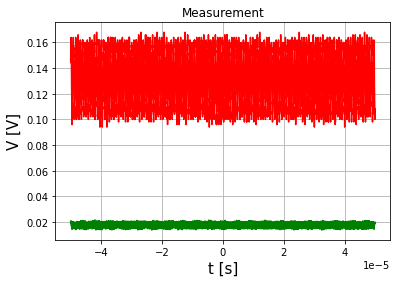

In [4]:
fig,ax=plt.subplots()
ax.plot(df['time'],df['amp_ch1'],c='green')
ax.plot(df['time'],df['amp_ch2'],c='red')
ax.grid()
ax.set_title('Measurement')
ax.set_xlabel('t [s]',size=15)
ax.set_ylabel('V [V]',size=15)

plt.savefig('measurement.jpg',dpi=300)

In [9]:
# number of fringes
fringes=[len(find_peaks(df[x],prominence=(df[x].max()-df[x].min())*0.5)[0]) for x in ['amp_ch1','amp_ch2']]
fringes

[202, 178]

# FOURIER 

In [6]:
fch1=np.fft.fft(df["amp_ch1"])
fch2=np.fft.fft(df["amp_ch2"])

fch1=fch1[1:]
fch2=fch2[1:]
freqs=np.fft.fftfreq(len(fch1))

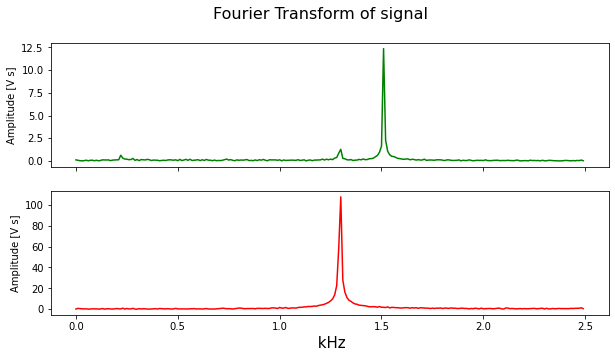

In [8]:
fig,ax=plt.subplots(nrows=2,sharex=True,figsize=(10,5))
n=250
m=0
X=freqs[m:n]*100
Y1=np.abs(fch1)[m:n]
Y2=np.abs(fch2)[m:n]
fig.suptitle('Fourier Transform of signal', fontsize=16)
ax[0].plot(X,Y1,c='green')
ax[0].set_ylabel('Amplitude [V s]')
ax[1].plot(X,Y2,c='red')
ax[1].set_ylabel('Amplitude [V s]')
ax[1].set_xlabel(r' kHz',size=15)

plt.savefig('fourier.jpg',dpi=300)

# RESULTS

In [10]:
main=[freqs[np.argmax(np.abs(x))] for x in [fch1,fch2]]
ratio=main[1]/main[0]

print(main,ratio)

[0.015103020604120825, 0.01300260052010402] 0.8609271523178808


In [11]:
wavelength_red=632.8 #nm
wavelength_green=wavelength_red*ratio
print(wavelength_green)

544.794701986755


In [19]:
freqs=np.fft.fftfreq(len(fch1))*100
main=np.array([freqs[np.argmax(np.abs(x))] for x in [fch1,fch2]])*100
spread=np.array([peak_widths(x,[np.argmax(x)])[0][0]*.5 for x in [fch1,fch2]])

/usr/lib/python3/dist-packages/scipy/signal/_peak_finding.py:261: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


In [23]:
red=632.8
green=red*main[-1]/main[0]
uncertanty=(np.sum(spread/main)+.1/red)*green
print(f'Green wavelenghth: {green} +/- {uncertanty}')

Green wavelenghth: 544.7947019867547 +/- 4.169067523824274
